In [42]:
# Data manipulation
import pandas as pd
import numpy as np
import sys
from pathlib import Path
%load_ext autoreload
%autoreload 2
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.config import BRENT_DATA,EVENT_DATA
# Visualization
import matplotlib.pyplot as plt
from src.preprocessing import (
    load_oil_data,
    preprocess_dates,
    compute_log_returns,
    compute_rolling_volatility
)

from src.visualizations import (
    plot_price,
    plot_log_returns,
    plot_volatility
)
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load the Brent Oil Dataset

In [43]:
oil_df = load_oil_data(BRENT_DATA)

# Load the Event Dataset

In [44]:
events_df = load_oil_data(EVENT_DATA)

# Inspect Both Datasets

In [45]:
print("="*50)
print("BRENT OIL DATASET")
print("="*50)

oil_df.info()

BRENT OIL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9011 non-null   str    
 1   Price   9011 non-null   float64
dtypes: float64(1), str(1)
memory usage: 140.9 KB


In [46]:
print("="*50)
print("EVENT DATASET")
print("="*50)

events_df.info()

EVENT DATASET
<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 4 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   Date                                 29 non-null     str  
 1   Event                                29 non-null     str  
 2   Category                             29 non-null     str  
 3   Expected Impact on Brent Oil Prices  29 non-null     str  
dtypes: str(4)
memory usage: 1.0 KB


In [47]:
oil_df = preprocess_dates(oil_df)

In [48]:
events_df = preprocess_dates(events_df)

# Check Missing Values

In [49]:
print("Oil Dataset")

oil_df.isnull().sum()

Oil Dataset


Date     0
Price    0
dtype: int64

In [50]:
print("Event Dataset")

events_df.isnull().sum()

Event Dataset


Date                                   0
Event                                  0
Category                               0
Expected Impact on Brent Oil Prices    0
dtype: int64

# Check Duplicate Records

In [51]:
print("Oil duplicates:", oil_df.duplicated().sum())

print("Event duplicates:", events_df.duplicated().sum())

Oil duplicates: 0
Event duplicates: 0


# Check Date Ranges

In [52]:
print("Oil Data")

print("Start:", oil_df["Date"].min())

print("End:", oil_df["Date"].max())

Oil Data
Start: 1987-05-20 00:00:00
End: 2022-11-14 00:00:00


In [53]:
print("Events")

print("Start:", events_df["Date"].min())

print("End:", events_df["Date"].max())

Events
Start: 1988-11-28 00:00:00
End: 2024-06-02 00:00:00


# Event Categories Distribution

In [54]:
events_df["Category"].value_counts()

Category
Geopolitical        11
OPEC+ Decision       6
OPEC Decision        5
Economic Shock       3
Supply Shock         2
Natural Disaster     1
Market Event         1
Name: count, dtype: int64

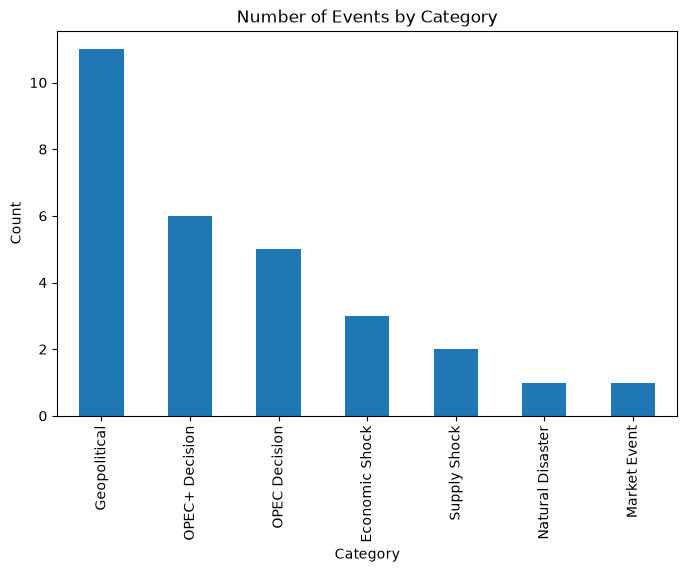

In [55]:
events_df["Category"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Number of Events by Category")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

# Oil Prices Plot

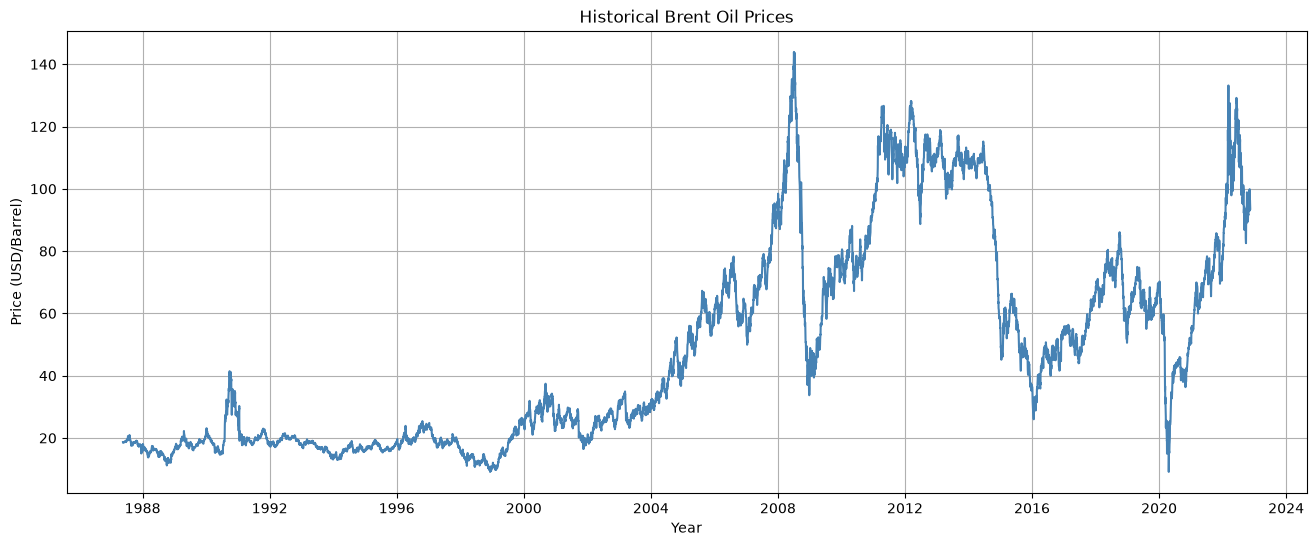

In [56]:
plot_price(oil_df)

# Overlay Historical Events

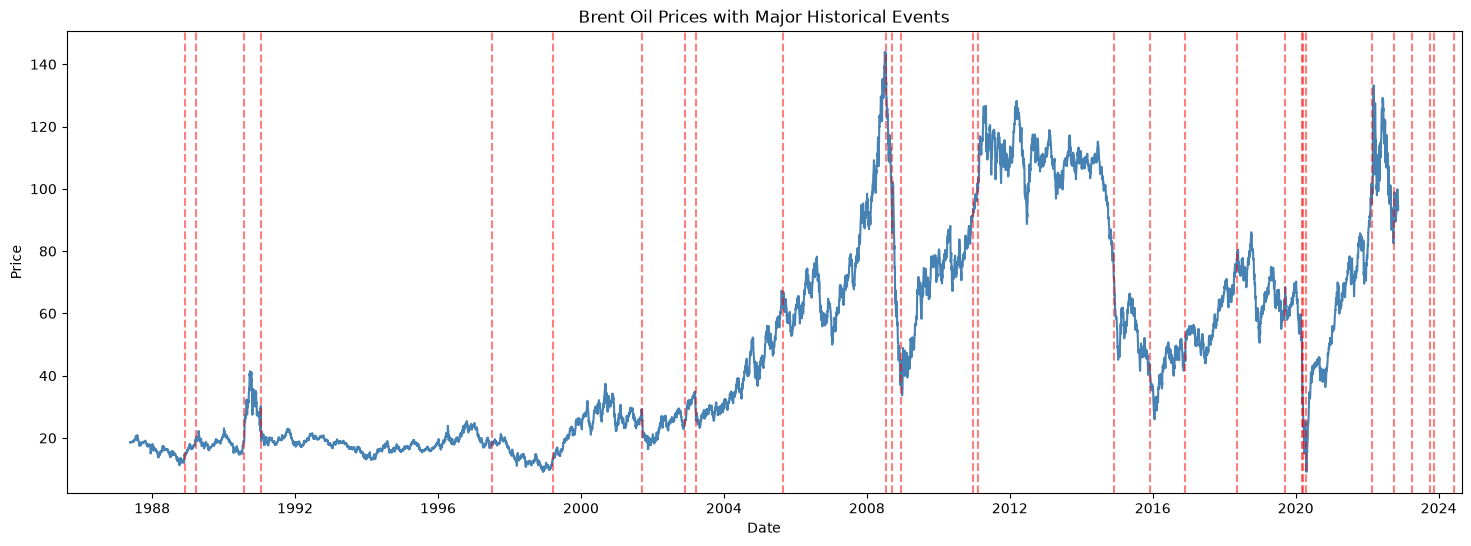

In [57]:
plt.figure(figsize=(18,6))

plt.plot(
    oil_df["Date"],
    oil_df["Price"],
    color="steelblue"
)

for _, row in events_df.iterrows():
    plt.axvline(
        row["Date"],
        color="red",
        alpha=0.5,
        linestyle="--"
    )

plt.title("Brent Oil Prices with Major Historical Events")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

# Save Cleaned Datasets

In [58]:
oil_df.to_csv(
    "../data/processed/brent_clean.csv",
    index=False
)

events_df.to_csv(
    "../data/processed/events_clean.csv",
    index=False
)

In [59]:
oil_df["MA90"] = oil_df["Price"].rolling(window=90).mean()

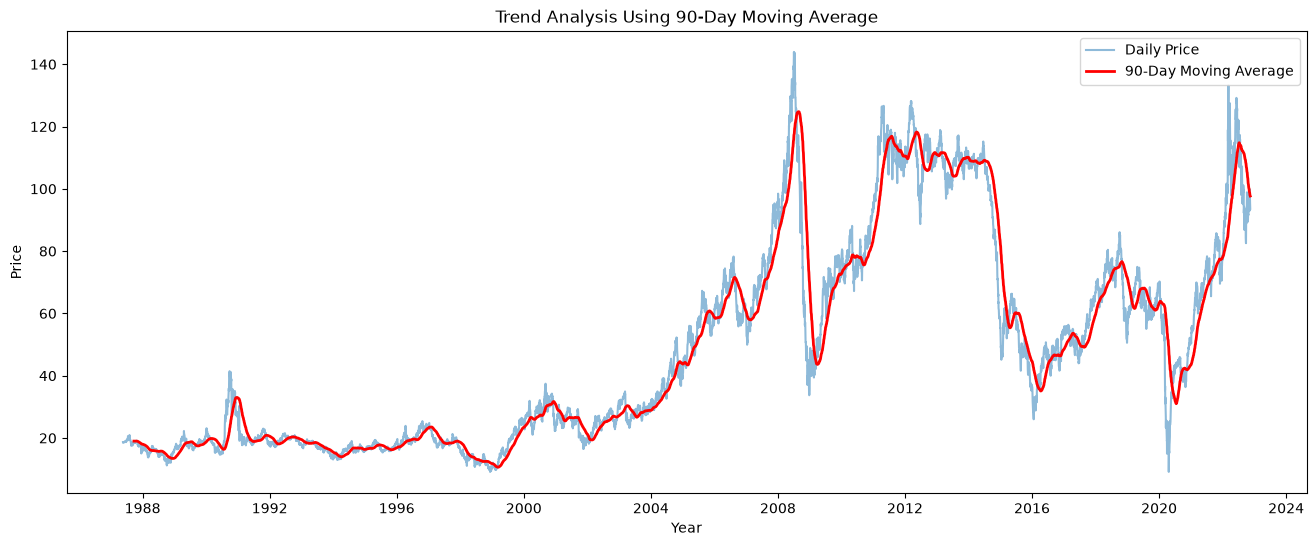

In [60]:
plt.figure(figsize=(16,6))

plt.plot(
    oil_df["Date"],
    oil_df["Price"],
    alpha=0.5,
    label="Daily Price"
)

plt.plot(
    oil_df["Date"],
    oil_df["MA90"],
    linewidth=2,
    color="red",
    label="90-Day Moving Average"
)

plt.title("Trend Analysis Using 90-Day Moving Average")

plt.xlabel("Year")
plt.ylabel("Price")

plt.legend()

plt.show()

# Stationarity Testing

In [61]:
from statsmodels.tsa.stattools import adfuller

In [62]:
result = adfuller(oil_df["Price"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -1.9938560113924675
p-value: 0.28927350489340287
Critical Values:
1%: -3.4310783342658615
5%: -2.861861876398633
10%: -2.566941329781918


In [63]:
if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is NOT stationary.")

The series is NOT stationary.


# Rolling Statistics

In [64]:
oil_df["Rolling Mean"] = oil_df["Price"].rolling(30).mean()

oil_df["Rolling Std"] = oil_df["Price"].rolling(30).std()

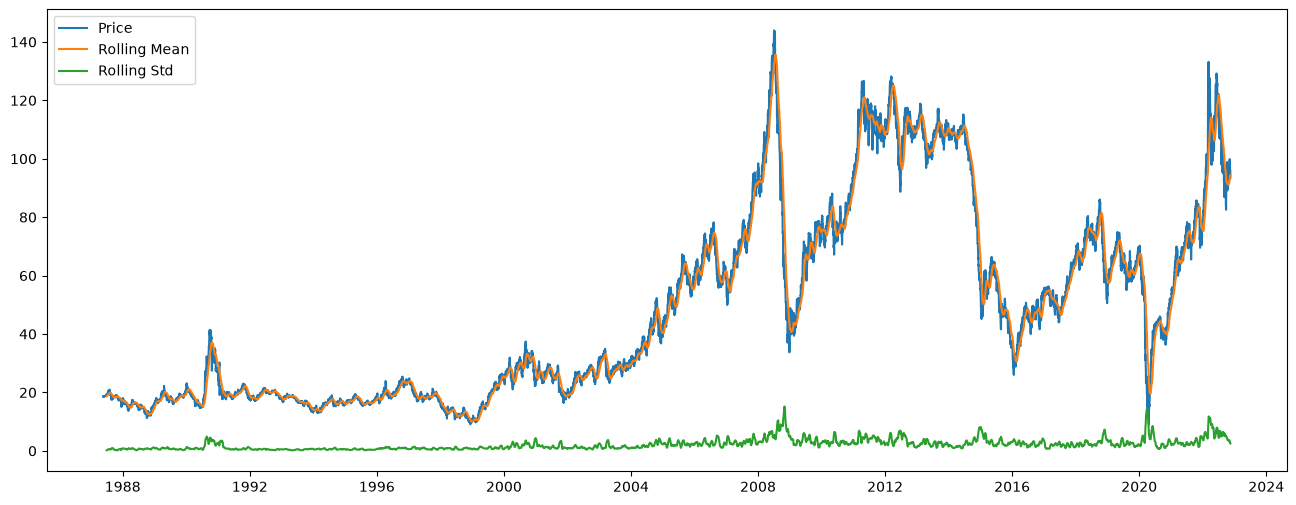

In [36]:
plt.figure(figsize=(16,6))

plt.plot(oil_df["Date"], oil_df["Price"], label="Price")

plt.plot(oil_df["Date"], oil_df["Rolling Mean"], label="Rolling Mean")

plt.plot(oil_df["Date"], oil_df["Rolling Std"], label="Rolling Std")

plt.legend()

plt.show()

# Volatility Analysis

In [65]:
oil_df["Return"] = oil_df["Price"].pct_change()

In [68]:
oil_df["RollingVolatility"] = oil_df["Return"].rolling(30).std()

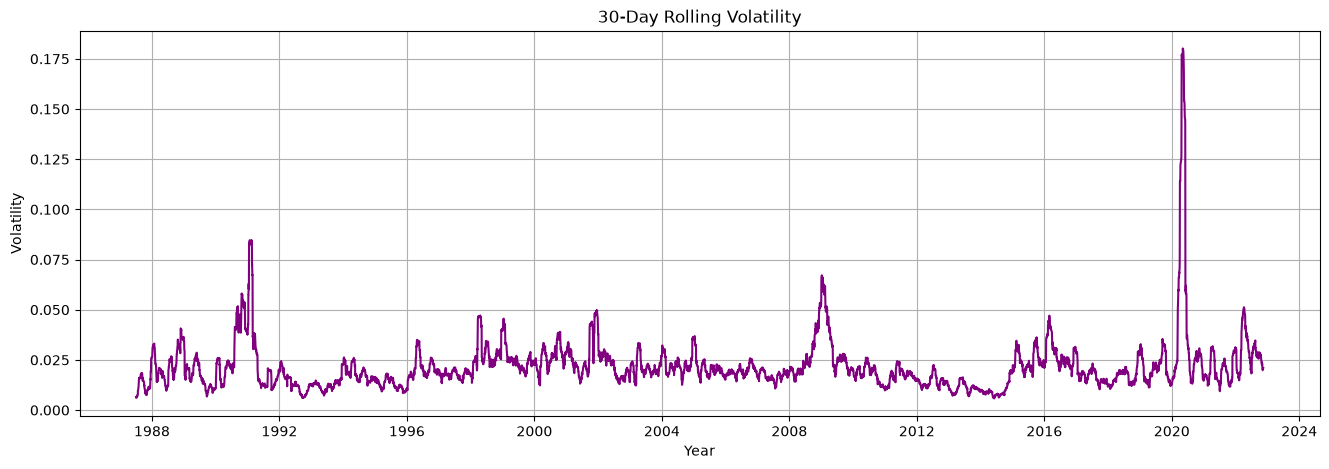

In [69]:
plot_volatility(oil_df)

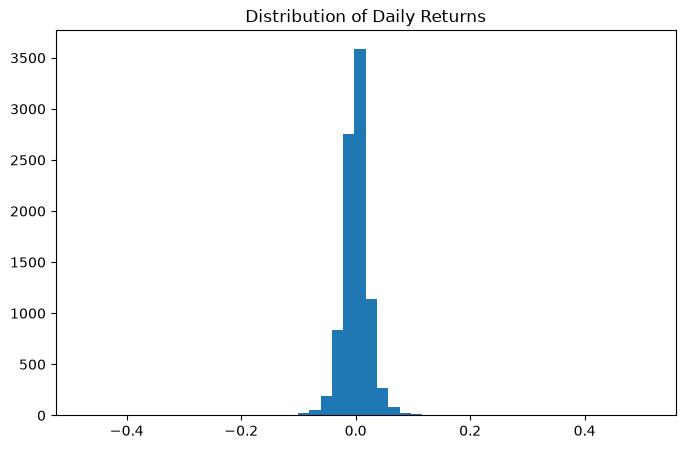

In [70]:
plt.figure(figsize=(8,5))

plt.hist(
    oil_df["Return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")

plt.show()